<a href="https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/deep_learning/DLinear/dlinear_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DLinear raw-pipeline inference

This notebook does inference only:

```text
W&B Model Registry
→ download self-contained DLinear pipeline
→ pipeline.predict(raw test.csv)
→ Kaggle submission + W&B submission artifact
```

It does not load a checkpoint directly, rebuild training history, or recreate DLinear preprocessing. Those responsibilities belong to `model_experiment_DLinear.ipynb`, which packages the selected best model as `Walmart_DLinear_Raw_Pipeline`.

In [1]:
%pip install -q "torch>=2.3,<3" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "kaggle>=1.7,<2" "cloudpickle>=3,<4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 3.6 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import hashlib
import json
import platform
from pathlib import Path

import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb

pd.set_option("display.max_columns", 100)
print(
    {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    }
)

{'python': '3.12.13', 'torch': '2.11.0+cu128', 'cuda_available': True}


In [3]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")

Mounted at /content/drive


In [4]:
CONFIG = {
    "data_dir": "/content/drive/MyDrive/walmart_competition_data",
    "output_dir": "/content/drive/MyDrive/walmart_competition_inference/dlinear",
    "download_dir": "/content/artifacts/dlinear_raw_pipeline",
    "wandb_entity": "kende23-n-a",
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "raw_pipeline_registry_uri": "wandb-registry-model/Walmart_DLinear_Raw_Pipeline:champion",
    "raw_pipeline_filename": "walmart_dlinear_raw_pipeline.pkl",
    "submission_artifact_name": "dlinear-kaggle-submission",
    "submit_to_kaggle": False,
    "kaggle_competition": "walmart-recruiting-store-sales-forecasting",
}

DATA_DIR = Path(CONFIG["data_dir"])
OUTPUT_DIR = Path(CONFIG["output_dir"])
DOWNLOAD_DIR = Path(CONFIG["download_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

{'data_dir': '/content/drive/MyDrive/walmart_competition_data',
 'output_dir': '/content/drive/MyDrive/walmart_competition_inference/dlinear',
 'download_dir': '/content/artifacts/dlinear_raw_pipeline',
 'wandb_entity': 'kende23-n-a',
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'raw_pipeline_registry_uri': 'wandb-registry-model/Walmart_DLinear_Raw_Pipeline:champion',
 'raw_pipeline_filename': 'walmart_dlinear_raw_pipeline.pkl',
 'submission_artifact_name': 'dlinear-kaggle-submission',
 'submit_to_kaggle': False,
 'kaggle_competition': 'walmart-recruiting-store-sales-forecasting'}

## Load raw test data


In [5]:
# The model architecture, checkpoint, normalisation and historical context are inside the registered pipeline.
# No DLinear model class is recreated in inference.


## Download registered raw-input pipeline


In [6]:
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
required_test = {"Store", "Dept", "Date", "IsHoliday"}
missing_test = sorted(required_test.difference(test_raw.columns))
if missing_test:
    raise ValueError({"missing_raw_test_columns": missing_test})
test_raw = test_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
print(
    {
        "raw_test_rows": len(test_raw),
        "raw_test_columns": test_raw.columns.tolist(),
        "date_range": (
            str(test_raw["Date"].min().date()),
            str(test_raw["Date"].max().date()),
        ),
    }
)
display(test_raw.head())

{'raw_test_rows': 115064, 'raw_test_columns': ['Store', 'Dept', 'Date', 'IsHoliday'], 'date_range': ('2012-11-02', '2013-07-26')}


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


## Start W&B inference run and download the registered raw-input pipeline


In [7]:
run = wandb.init(
    project=CONFIG["wandb_project"],
    entity=CONFIG["wandb_entity"],
    job_type="dlinear_raw_pipeline_inference",
    name="dlinear_registry_raw_pipeline_inference",
    config=CONFIG,
)

pipeline_artifact = run.use_artifact(CONFIG["raw_pipeline_registry_uri"])
pipeline_dir = Path(pipeline_artifact.download(root=str(DOWNLOAD_DIR)))
pipeline_path = pipeline_dir / CONFIG["raw_pipeline_filename"]
if not pipeline_path.exists():
    candidates = sorted(pipeline_dir.glob("*.pkl"))
    if len(candidates) != 1:
        raise FileNotFoundError(
            {"expected": str(pipeline_path), "candidates": [str(p) for p in candidates]}
        )
    pipeline_path = candidates[0]

with pipeline_path.open("rb") as file:
    pipeline = cloudpickle.load(file)
print(
    {
        "registry_artifact": pipeline_artifact.name,
        "pipeline_path": str(pipeline_path),
        "pipeline_type": type(pipeline).__name__,
        "pipeline_metadata": pipeline.metadata(),
    }
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   3 of 3 files downloaded.  


{'registry_artifact': 'Walmart_DLinear_Raw_Pipeline:champion', 'pipeline_path': '/content/artifacts/dlinear_raw_pipeline/walmart_dlinear_raw_pipeline.pkl', 'pipeline_type': 'DLinearRawPipeline', 'pipeline_metadata': {'pipeline_type': 'DLinearRawPipeline', 'input_weeks': 52, 'prediction_weeks': 39, 'moving_avg_kernel': 25, 'stored_series': 3331, 'stored_history_rows': 421570, 'raw_input_columns': ['Date', 'Dept', 'IsHoliday', 'Store'], 'cold_start_fallback': '0.0, matching the selected DLinear inference contract'}}


## Predict directly from raw test rows


In [8]:
test_pred = np.asarray(pipeline.predict(test_raw), dtype=np.float64)
if len(test_pred) != len(test_raw):
    raise ValueError(
        f"Pipeline returned {len(test_pred)} predictions for {len(test_raw)} raw rows."
    )
if not np.isfinite(test_pred).all():
    raise ValueError("Pipeline produced non-finite predictions.")
if (test_pred < 0).any():
    raise ValueError("Pipeline produced negative predictions after clipping.")

print(
    {
        "prediction_shape": test_pred.shape,
        "prediction_min": float(test_pred.min()),
        "prediction_mean": float(test_pred.mean()),
        "prediction_max": float(test_pred.max()),
        "prediction_sha256": hashlib.sha256(
            test_pred.astype(np.float32).tobytes()
        ).hexdigest(),
    }
)

{'prediction_shape': (115064,), 'prediction_min': 0.0, 'prediction_mean': 15761.628184238567, 'prediction_max': 193871.3125, 'prediction_sha256': 'dfa09de2ef105a90f9bd1077a6b4bfd396c3444745cbffae50f4038e553f7d3a'}


## Build Kaggle submission


In [9]:
submission = test_raw[["Store", "Dept", "Date"]].copy()
submission["Weekly_Sales"] = test_pred
submission.insert(
    0,
    "Id",
    submission["Store"].astype(str)
    + "_"
    + submission["Dept"].astype(str)
    + "_"
    + submission["Date"].dt.strftime("%Y-%m-%d"),
)
submission = submission[["Id", "Weekly_Sales"]]

submission_path = OUTPUT_DIR / "submission_dlinear_registry_raw_pipeline.csv"
submission.to_csv(submission_path, index=False)
print({"submission_path": str(submission_path), "rows": len(submission)})
display(submission.head())

{'submission_path': '/content/drive/MyDrive/walmart_competition_inference/dlinear/submission_dlinear_registry_raw_pipeline.csv', 'rows': 115064}


,Id,Weekly_Sales
0,1_1_2012-11-02,27570.369141
1,1_1_2012-11-09,23621.726562
2,1_1_2012-11-16,22035.128906
3,1_1_2012-11-23,21694.162109
4,1_1_2012-11-30,21859.845703


## Log inference diagnostics and submission artifact


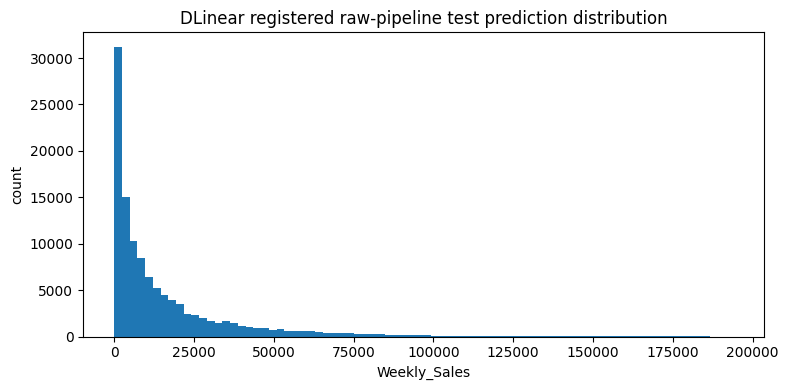

{'registry_pipeline_uri': 'wandb-registry-model/Walmart_DLinear_Raw_Pipeline:champion',
 'registry_pipeline_artifact': 'Walmart_DLinear_Raw_Pipeline:champion',
 'pipeline_type': 'DLinearRawPipeline',
 'pipeline_metadata': {'pipeline_type': 'DLinearRawPipeline',
  'input_weeks': 52,
  'prediction_weeks': 39,
  'moving_avg_kernel': 25,
  'stored_series': 3331,
  'stored_history_rows': 421570,
  'raw_input_columns': ['Date', 'Dept', 'IsHoliday', 'Store'],
  'cold_start_fallback': '0.0, matching the selected DLinear inference contract'},
 'test_rows': 115064,
 'submission_rows': 115064,
 'prediction_min': 0.0,
 'prediction_mean': 15761.628184238567,
 'prediction_max': 193871.3125,
 'prediction_sha256': 'dfa09de2ef105a90f9bd1077a6b4bfd396c3444745cbffae50f4038e553f7d3a'}

In [10]:
manifest = {
    "registry_pipeline_uri": CONFIG["raw_pipeline_registry_uri"],
    "registry_pipeline_artifact": pipeline_artifact.name,
    "pipeline_type": type(pipeline).__name__,
    "pipeline_metadata": pipeline.metadata(),
    "test_rows": int(len(test_raw)),
    "submission_rows": int(len(submission)),
    "prediction_min": float(submission["Weekly_Sales"].min()),
    "prediction_mean": float(submission["Weekly_Sales"].mean()),
    "prediction_max": float(submission["Weekly_Sales"].max()),
    "prediction_sha256": hashlib.sha256(
        test_pred.astype(np.float32).tobytes()
    ).hexdigest(),
}
manifest_path = OUTPUT_DIR / "dlinear_raw_pipeline_inference_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(submission["Weekly_Sales"], bins=80)
ax.set_title("DLinear registered raw-pipeline test prediction distribution")
ax.set_xlabel("Weekly_Sales")
ax.set_ylabel("count")
plt.tight_layout()
hist_path = OUTPUT_DIR / "dlinear_raw_pipeline_prediction_hist.png"
fig.savefig(hist_path, dpi=160)
plt.show()

run.log(
    {
        "inference/prediction_min": manifest["prediction_min"],
        "inference/prediction_mean": manifest["prediction_mean"],
        "inference/prediction_max": manifest["prediction_max"],
        "inference/submission_rows": manifest["submission_rows"],
        "inference/submission_preview": wandb.Table(dataframe=submission.head(2000)),
        "inference/prediction_histogram": wandb.Image(str(hist_path)),
    }
)

submission_artifact = wandb.Artifact(
    CONFIG["submission_artifact_name"], type="submission"
)
for artifact_path in [submission_path, manifest_path, hist_path]:
    submission_artifact.add_file(str(artifact_path))
run.log_artifact(submission_artifact, aliases=["registry-raw-pipeline", "latest"])
run.summary.update(manifest)

manifest

## Optional Kaggle submission upload


In [11]:
if CONFIG["submit_to_kaggle"]:
    try:
        from google.colab import userdata
        import os

        os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
        os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    except Exception as exc:
        print("Could not load Kaggle secrets from Colab userdata:", exc)

    import subprocess

    cmd = [
        "kaggle",
        "competitions",
        "submit",
        "-c",
        CONFIG["kaggle_competition"],
        "-f",
        str(submission_path),
        "-m",
        "DLinear W&B registered raw-pipeline inference",
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
else:
    print("Kaggle upload disabled. Set CONFIG['submit_to_kaggle'] = True to upload.")

Kaggle upload disabled. Set CONFIG['submit_to_kaggle'] = True to upload.


In [12]:
run.finish()

inference/prediction_max,▁
inference/prediction_mean,▁
inference/prediction_min,▁
inference/submission_rows,▁
inference/prediction_max,193871.3125
inference/prediction_mean,15761.62818
inference/prediction_min,0
inference/submission_rows,115064
pipeline_type,DLinearRawPipeline
prediction_max,193871.3125
prediction_mean,15761.62818
